In [14]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import maptools
import os
import matplotlib.pyplot as plt
import h5py

maptools.job.info()
maptools.plot.dark()
!which python

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
hostname: offline-fe1
SLURM_JOB_ID: None
SLURM_JOB_NODELIST: None
NPROCS: 40
Memory available: 65.575497728 GB
~/.conda/envs/grainmapper/bin/python


In [15]:
# Good scanning 3dxrd files are:
scans = maptools.constants.SCANRANGES
sample = "al1050_15pct_center_slice"
dataset = "scan-0053.h5"
dataroot = maptools.paths.RAW
analysisroot = os.path.join(maptools.paths.PROCESS, sample)
datapath = os.path.join(dataroot, sample, dataset)
maskfile = maptools.constants.PILATUS_MASK

In [16]:
maptools.io.check_metadata(datapath)
number_of_dty_scans_in_file = maptools.io.get_number_of_dty_scans_in_file(datapath)
frames = maptools.io.get_frames(datapath)
omega = maptools.io.get_omega(datapath)
dty = maptools.io.get_dty(datapath)
omsteps_per_scan = maptools.constants.NUMBER_OF_OMEGA_STEPS

number of dty scans in file: 17
number of omega steps per dty scan: 3003
number of frames in file: 51051
Detector shape: (1679, 1475)


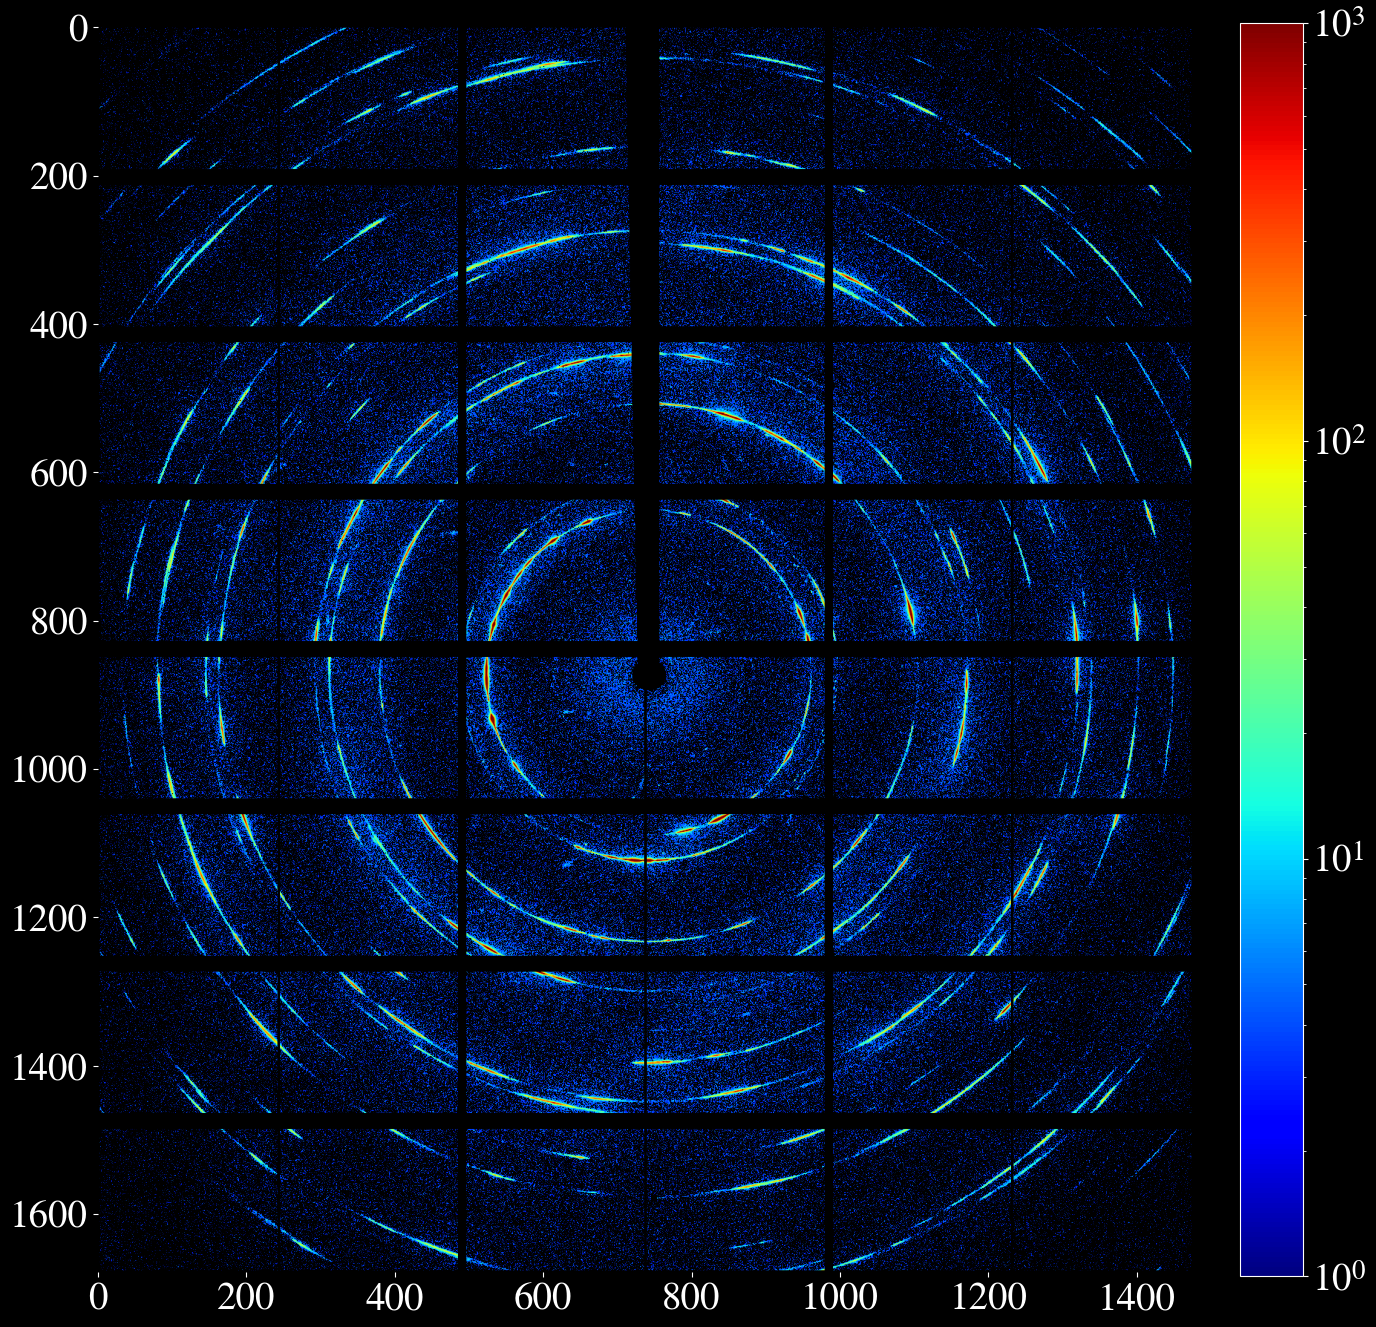

In [17]:
_s = frames[100:108].sum(axis=0).astype(np.float32)
_s[maskfile == 1] = np.nan
_s[_s < 3] = np.nan

fig, ax = plt.subplots(1, 1, figsize=(14, 14))
im = ax.imshow(_s, vmin=1, vmax=1000, norm="log", cmap="jet")
fig.colorbar(im, ax=ax, fraction=0.052, pad=0.04)
plt.tight_layout()
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

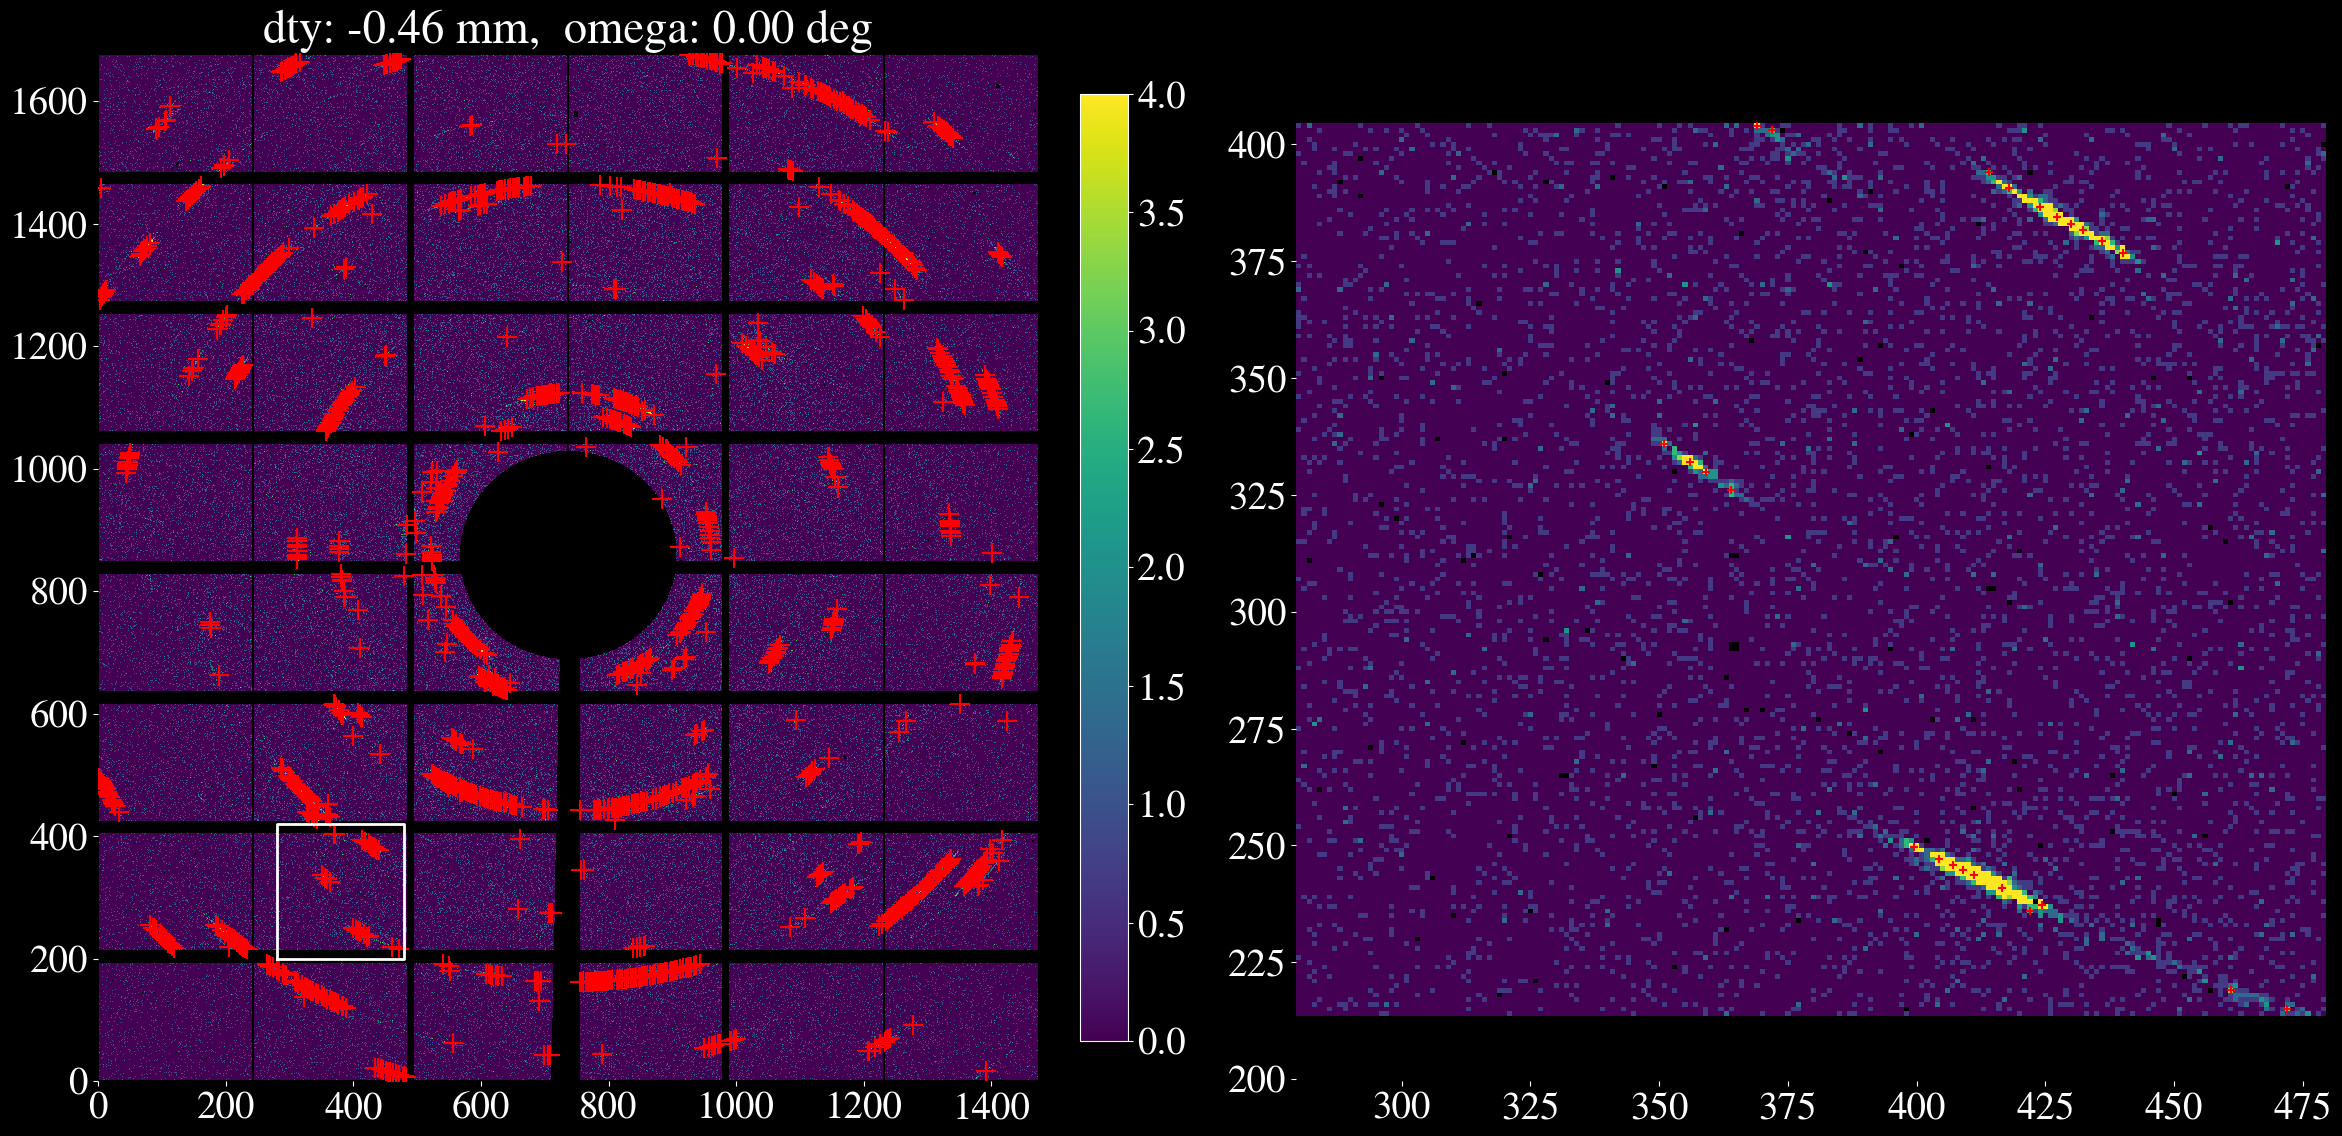

In [18]:
mask = maskfile == 0
ii, jj = np.indices(mask.shape)
ii = ii - np.median(ii) - 20
jj = jj - np.median(jj)
circ = (ii**2 + jj**2) > 170**2
mask = mask * circ

good_pixels_mask = mask.copy()
bad_pixels_mask = ~mask

options = {
    "bgfile": None,
    "maskfile": bad_pixels_mask,
    "threshold": 4,
    "smoothsigma": 0.0,
    "bgc": 0.0,
    "minpx": 1,
    "m_offset_thresh": 0,
    "m_ratio_thresh": 0,
}

frame_index = 3003
with h5py.File(
    "/data/visitors/danmax/20251117/2025110808/raw/al1050_15pct_center_slice/scan-0050.h5",
    "r",
) as f:
    raw_image = f["entry/measurement/pilatus"][frame_index]
    _omega = f[maptools.paths.OMEGAMOTOR][frame_index]
    _dty = f[maptools.paths.DTYMOTOR][frame_index]


image_worker, fc, sc, npks = maptools.segmenter.segment_frame(raw_image, options)

fig, ax = plt.subplots(1, 2, figsize=(24, 12))

smoothed_image = image_worker.smoothed.copy()
smoothed_image[maskfile == 1] = np.nan

X, Y = np.meshgrid(
    np.arange(smoothed_image.shape[1]), np.arange(smoothed_image.shape[0])
)
_s = raw_image.copy().astype(np.float32)

_s[bad_pixels_mask] = np.nan
im = ax[0].pcolormesh(X, Y, _s, cmap="viridis", vmin=0, vmax=4, shading="nearest")
ax[0].scatter(fc, sc, marker="+", c="r", s=200)
fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
roi = (200, 420, 280, 480)

ax[0].plot(
    [roi[2], roi[2], roi[3], roi[3], roi[2]],
    [roi[0], roi[1], roi[1], roi[0], roi[0]],
    c="w",
    lw=2,
)
ax[0].set_title(f"dty: {_dty:.2f} mm,  omega: {_omega:.2f} deg")

# sc is row, fc is column
xx = X[roi[0] : roi[1], roi[2] : roi[3]]
yy = Y[roi[0] : roi[1], roi[2] : roi[3]]
_s = raw_image[roi[0] : roi[1], roi[2] : roi[3]].astype(np.float32)
_s[bad_pixels_mask[roi[0] : roi[1], roi[2] : roi[3]]] = np.nan
ax[1].pcolormesh(xx, yy, _s, cmap="viridis", vmin=0, vmax=6, shading="nearest")
_mask = (sc < roi[1]) * (sc > roi[0]) * (fc < roi[3]) * (fc > roi[2])
ax[1].scatter(fc[_mask], sc[_mask], marker="+", c="r")

for a in ax.flatten():
    for spine in a.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

np.save("segmenter_options.npy", options, allow_pickle=True)
